# ERA5 data

```{note}
The online laboratory has only been tested in recent Firefox and Chrome browsers. Some features may not (yet) be supported in Safari browsers.
```

```{caution}
In the online laboratory, changes to notebooks and local files are only saved in your web browser's storage and not persisted to disk.

Please download copies of any files that you don't want to lose.

Your files from an old session will usually be kept if you close or refresh this page, unless your browser's storage for `lab.climet.eu` is cleared, e.g.
- manually by clearing the browser's site data
- automatically when too much data is stored
- automatically when you close a private browsing context
- if you have set up your browser to clear site data, e.g. when the browser is closed
```

This notebook shows how to load and plot selected ERA5 fields stored in the [ECMWF S3 bucket](https://object-store.os-api.cci1.ecmwf.int/esiwacebucket/ERA5_07_2026/).

The GRIB files are large. This notebook uses `gribscan` reference files, like `01-hplp.ipynb`, so the full GRIB files are not downloaded in normal notebook use. The `.ref` files point to byte ranges in the S3 GRIB objects and `xarray` reads only the chunks needed for the selected data.

---

## Dataset Details

The available data contain ERA5 fields for July 2026. Two GRIB files are available:

| Dataset | File | Frequency | Notes |
|:--|:--|:--|:--|
| Pressure levels | `era5_pressure_50_500_850_1000_202607_3h.grib` | 3-hourly | Pressure-level data on 50, 500, 850, and 1000 hPa |
| Single levels | `era5_single_202607_6h.grib` | 6-hourly | Single-level ERA5 fields |

## Reference Files

Fast random access requires reference metadata for each GRIB file. Generate it once with `generate_ref.py`, then upload the resulting `.ref` files and `.refs.json` catalog next to the GRIB file.

Offsets are file-specific. If you create a new ERA5 GRIB file, for example hourly August data with a different variable list, generate new reference files for that GRIB. Reusing references from another GRIB file is not safe.

Example preprocessing commands:

```bash
python generate_ref.py era5_pressure_50_500_850_1000_202607_3h.grib \
  --remote-url https://object-store.os-api.cci1.ecmwf.int/esiwacebucket/ERA5_07_2026/era5_pressure_50_500_850_1000_202607_3h.grib

python generate_ref.py era5_single_202607_6h.grib \
  --remote-url https://object-store.os-api.cci1.ecmwf.int/esiwacebucket/ERA5_07_2026/era5_single_202607_6h.grib
```

## Using the `load_era5_data` Function

To load selected ERA5 fields, use:

```python
load_era5_data(leveltype=None, param=None, time=None, level=None, area=None)
```

### Parameters

- **`leveltype`**: `"pressure"` or `"single"` for the default July 2026 files.
- **`param`**: GRIB short name or list of short names, for example `"t"`, `"z"`, `"q"`, `"u"`, `"v"`, `"2t"`, `"10u"`, `"10v"`, `"msl"`, `"ssr"`, or any other short name present in the reference catalog.
- **`time`**: Optional single datetime string or list of datetime strings.
- **`level`**: Optional level selection. Use this for pressure-level fields only.
- **`area`**: Optional geographic subset as `(north, west, south, east)` in degrees.
- **`catalog_url` / `catalog_path`**: Optional custom catalog location for another GRIB file.
- **`ref_url` / `ref_path`**: Optional direct reference file location if you already know which group to open.

In [12]:
import json
import sys
from functools import lru_cache
from pathlib import Path
from urllib.parse import urljoin

import numpy as np
import pandas as pd
import requests
import xarray as xr

sys.path.insert(0, "..")
import utils

In [13]:
BASE_URL = "https://object-store.os-api.cci1.ecmwf.int/esiwacebucket"

ERA5_SOURCES = {
    "pressure": {
        "ref_url": f"{BASE_URL}/ERA5_07_2026/era5_pressure_50_500_850_1000_202607_3h.grib.ref",
        "catalog_url": f"{BASE_URL}/ERA5_07_2026/era5_pressure_50_500_850_1000_202607_3h.grib.refs.json",
    },
    "single": {
        "catalog_url": f"{BASE_URL}/ERA5_07_2026/era5_single_202607_6h.grib.refs.json",
    },
}

Define the loader. It opens only the reference group(s) containing the requested variable names, then applies the time, level, and area selection lazily.

In [14]:
def _as_list(value):
    if value is None or isinstance(value, (str, bytes)):
        return [value]
    return list(value)


def _load_json(location):
    if str(location).startswith(("http://", "https://")):
        response = requests.get(location)
        response.raise_for_status()
        return response.json()
    return json.loads(Path(location).read_text())


@lru_cache(maxsize=None)
def _remote_json(location):
    return _load_json(location)


def load_era5_catalog(leveltype=None, catalog_url=None, catalog_path=None):
    if catalog_path is not None:
        return _load_json(catalog_path)
    if catalog_url is None:
        if leveltype not in ERA5_SOURCES:
            raise ValueError("Use leveltype='pressure' or leveltype='single'.")
        catalog_url = ERA5_SOURCES[leveltype]["catalog_url"]
    return _remote_json(catalog_url)


def _ref_location(ref_name, catalog_url=None, catalog_path=None):
    if str(ref_name).startswith(("http://", "https://")):
        return ref_name
    if catalog_path is not None:
        return Path(catalog_path).parent / ref_name
    return urljoin(catalog_url, ref_name)


def _var_name(ds, param):
    aliases = {"2t": "t2m", "2d": "d2m", "10u": "u10", "10v": "v10"}
    for name in (param, aliases.get(param)):
        if name in ds.data_vars:
            return name
    return None

In [15]:
def _open_ref(ref_location):
    ref = _load_json(ref_location)
    return xr.open_dataset(
        "reference://",
        engine="zarr",
        backend_kwargs=dict(
            storage_options=dict(
                fo=ref, asynchronous=True, remote_options=dict(asynchronous=True)
            )
        ),
        consolidated=False,
        chunks=dict(),
    )


def _subset(ds, param=None, time=None, level=None, area=None):
    if param is not None:
        params = _as_list(param)
        names = [_var_name(ds, name) for name in params]
        missing = [param for param, name in zip(params, names) if name is None]
        if missing:
            raise KeyError(
                f"Variable(s) {missing} not found in this reference group. "
                f"Available variables: {list(ds.data_vars)}"
            )
        ds = ds[names]

    if time is not None and "time" in ds.coords:
        ds = ds.sel(time=[pd.Timestamp(t) for t in _as_list(time)])
    if level is not None and "level" in ds.coords:
        ds = ds.sel(level=level)

    if area is not None:
        north, west, south, east = area
        lon_name = "longitude" if "longitude" in ds.coords else "lon"
        lat_name = "latitude" if "latitude" in ds.coords else "lat"
        lon = ds[lon_name]

        if float(lon.min()) < 0:
            west = west - 360 if west > 180 else west
            east = east - 360 if east > 180 else east
        else:
            west = west % 360
            east = east % 360

        lat_mask = (ds[lat_name] >= south) & (ds[lat_name] <= north)
        if west <= east:
            lon_mask = (lon >= west) & (lon <= east)
        else:
            lon_mask = (lon >= west) | (lon <= east)
        ds = ds.where(lat_mask & lon_mask, drop=True).sortby(lon_name)
    return ds


def _groups_for_params(catalog, params):
    matches = []
    missing = set(params)
    for group in catalog["groups"].values():
        variables = set(group.get("variables", []))
        group_params = [param for param in params if param in variables]
        if group_params:
            matches.append((group, group_params))
            missing -= set(group_params)
    if missing:
        available = sorted({v for g in catalog["groups"].values() for v in g.get("variables", [])})
        raise ValueError(f"Parameters not found: {sorted(missing)}. Available: {available}")
    return matches

In [16]:
def load_era5_data(
    leveltype=None,
    param=None,
    time=None,
    level=None,
    area=None,
    catalog_url=None,
    catalog_path=None,
    ref_url=None,
    ref_path=None,
):
    if param is None:
        raise ValueError("Please specify a GRIB short name or list of short names.")

    params = _as_list(param)
    datasets = []

    if ref_url is None and ref_path is None and leveltype in ERA5_SOURCES:
        ref_url = ERA5_SOURCES[leveltype].get("ref_url")

    if ref_url is not None or ref_path is not None:
        ds = _open_ref(ref_path or ref_url)
        datasets.append(_subset(ds, params, time, level, area))
    else:
        catalog = load_era5_catalog(leveltype, catalog_url, catalog_path)
        catalog_url = catalog_url or ERA5_SOURCES[leveltype]["catalog_url"]
        for group, group_params in _groups_for_params(catalog, params):
            ref_location = _ref_location(group["ref"], catalog_url, catalog_path)
            datasets.append(_subset(_open_ref(ref_location), group_params, time, level, area))

    datasets = [ds for ds in datasets if ds.data_vars]
    if not datasets:
        raise ValueError("No variables matched the requested selection.")
    return datasets[0] if len(datasets) == 1 else xr.merge(datasets, join="outer", compat="override")


def era5_data_array(ds, param):
    name = _var_name(ds, param)
    if name is None:
        raise KeyError(f"Variable {param!r} not found. Available variables: {list(ds.data_vars)}")
    return ds[name]

You can inspect the available variables from the small catalog without touching the GRIB data.

In [17]:
catalog = load_era5_catalog(leveltype="pressure")
sorted({v for group in catalog["groups"].values() for v in group["variables"]})

['cc',
 'ciwc',
 'clwc',
 'crwc',
 'cswc',
 'd',
 'o3',
 'pv',
 'q',
 'r',
 't',
 'u',
 'v',
 'vo',
 'w',
 'z']

## Example Usage

The next example loads temperature at 850 hPa for one 3-hourly analysis time.

In [18]:
ds_t850 = load_era5_data(
    leveltype="pressure",
    param="t",
    level=850,
    time="2026-07-15T12:00:00",
)
ds_t850

<xarray.Dataset> Size: 8MB
Dimensions:  (time: 1, lat: 721, lon: 1440)
Coordinates:
  * time     (time) datetime64[ns] 8B 2026-07-15T12:00:00
  * lat      (lat) float64 6kB 90.0 89.75 89.5 89.25 ... -89.5 -89.75 -90.0
  * lon      (lon) float64 12kB 0.0 0.25 0.5 0.75 1.0 ... -1.0 -0.75 -0.5 -0.25
    level    int64 8B 850
Data variables:
    t        (time, lat, lon) float64 8MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
Attributes:
    edition:            1
    centre:             ecmf
    centreDescription:  European Centre for Medium-Range Weather Forecasts
    subCentre:          0
    history:            🪄🧙‍♂️🔮 magic dataset assembly provided by gribscan.IF...

The selected 850 hPa temperature field can now be plotted.

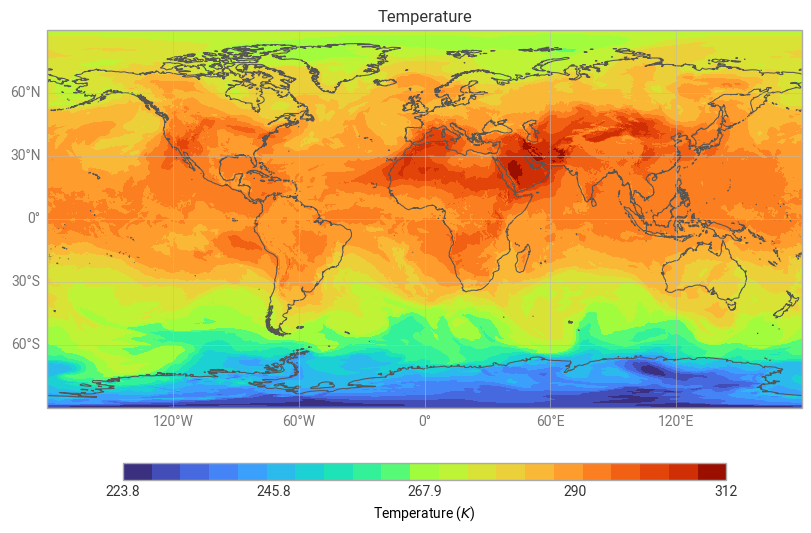

In [19]:
da_t850 = era5_data_array(ds_t850, "t").squeeze(drop=True)
utils.quickplot(da_t850, x="lon", y="lat")

The next example loads specific humidity at 1000 hPa over Europe and the North Atlantic.

In [20]:
ds_q = load_era5_data(
    leveltype="pressure",
    param="q",
    level=1000,
    time="2026-07-01T00:00:00",
    area=(75, -30, 25, 45),
)
ds_q

<xarray.Dataset> Size: 488kB
Dimensions:  (time: 1, lat: 201, lon: 301)
Coordinates:
  * time     (time) datetime64[ns] 8B 2026-07-01
  * lat      (lat) float64 2kB 75.0 74.75 74.5 74.25 ... 25.75 25.5 25.25 25.0
  * lon      (lon) float64 2kB -30.0 -29.75 -29.5 -29.25 ... 44.5 44.75 45.0
    level    int64 8B 1000
Data variables:
    q        (time, lat, lon) float64 484kB dask.array<chunksize=(1, 201, 301), meta=np.ndarray>
Attributes:
    edition:            1
    centre:             ecmf
    centreDescription:  European Centre for Medium-Range Weather Forecasts
    subCentre:          0
    history:            🪄🧙‍♂️🔮 magic dataset assembly provided by gribscan.IF...

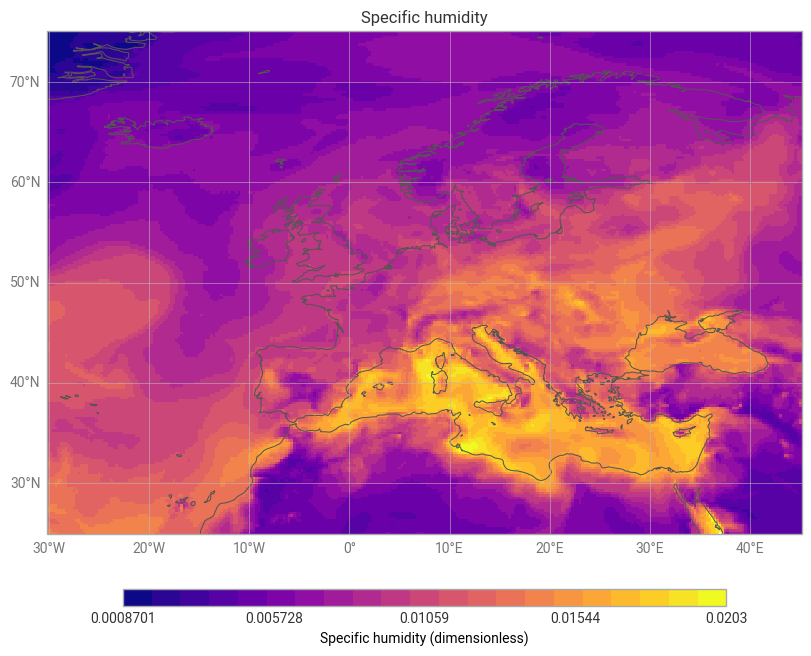

In [21]:
da_q = era5_data_array(ds_q, "q").squeeze(drop=True)
utils.quickplot(da_q, x="lon", y="lat")

The single-level file can also be used for common screen-level and surface fields. The next example loads 2 metre temperature.

In [22]:
ds_t2m = load_era5_data(
    leveltype="single",
    param="2t",
    time="2026-07-01T00:00:00",
)
ds_t2m

<xarray.Dataset> Size: 8MB
Dimensions:  (time: 1, lat: 721, lon: 1440)
Coordinates:
  * time     (time) datetime64[ns] 8B 2026-07-01
  * lat      (lat) float64 6kB 90.0 89.75 89.5 89.25 ... -89.5 -89.75 -90.0
  * lon      (lon) float64 12kB 0.0 0.25 0.5 0.75 1.0 ... -1.0 -0.75 -0.5 -0.25
Data variables:
    2t       (time, lat, lon) float64 8MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
Attributes:
    edition:            1
    centre:             ecmf
    centreDescription:  European Centre for Medium-Range Weather Forecasts
    subCentre:          0
    history:            🪄🧙‍♂️🔮 magic dataset assembly provided by gribscan.IF...

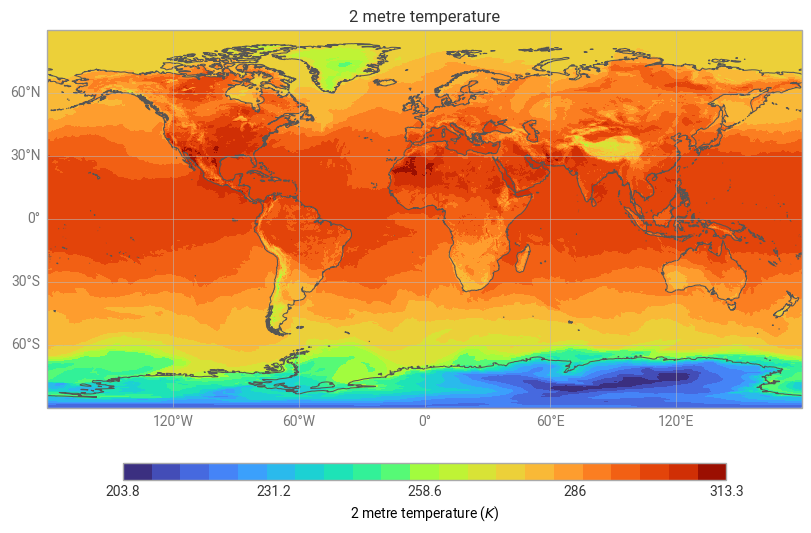

In [23]:
da_t2m = era5_data_array(ds_t2m, "2t").squeeze(drop=True)
utils.quickplot(da_t2m, x="lon", y="lat")

Multiple variables can be selected together. The following example loads 10 metre wind components and plots wind speed.

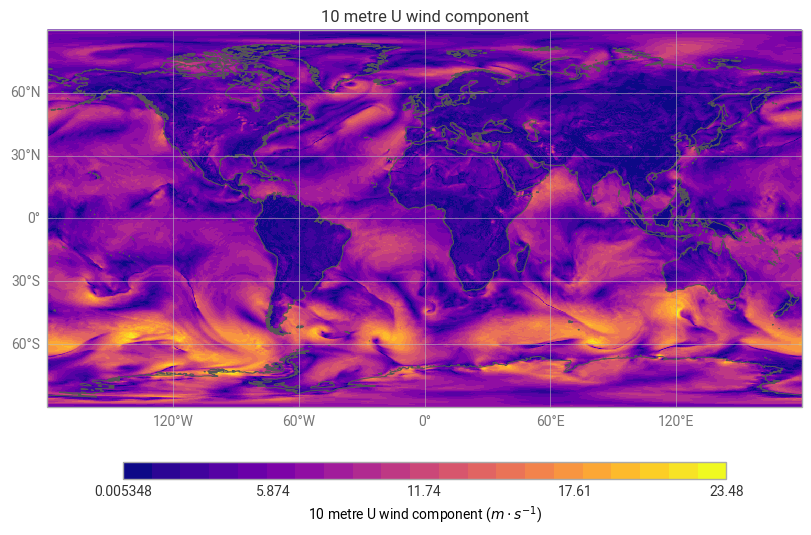

In [24]:
ds_wind = load_era5_data(
    leveltype="single",
    param=["10u", "10v"],
    time="2026-07-01T00:00:00",
)

u10 = era5_data_array(ds_wind, "10u").squeeze(drop=True)
v10 = era5_data_array(ds_wind, "10v").squeeze(drop=True)
wind_speed = np.hypot(u10, v10)

utils.quickplot(wind_speed, x="lon", y="lat")